# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution

In [3]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

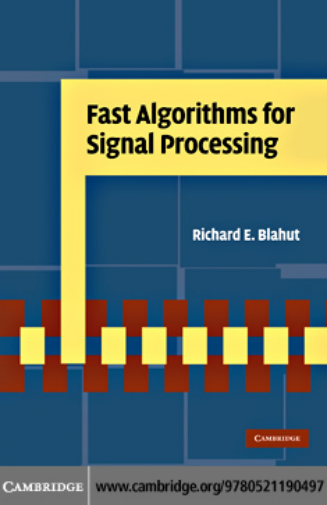

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

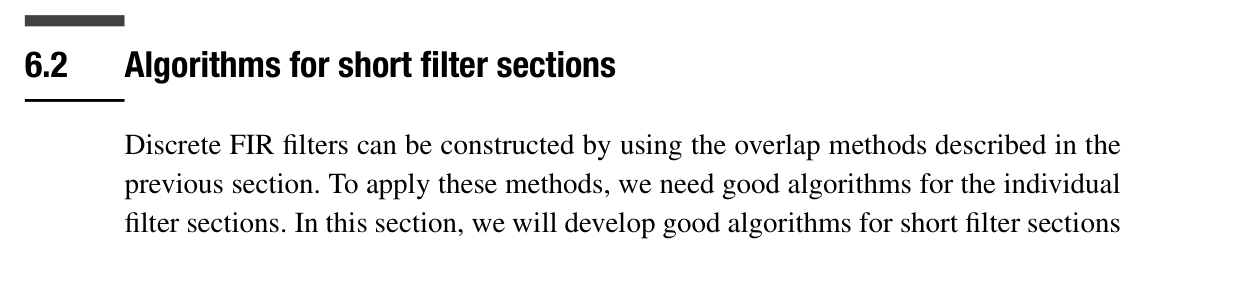

In [5]:
plot_pdf(doc[214], [.8, .95])

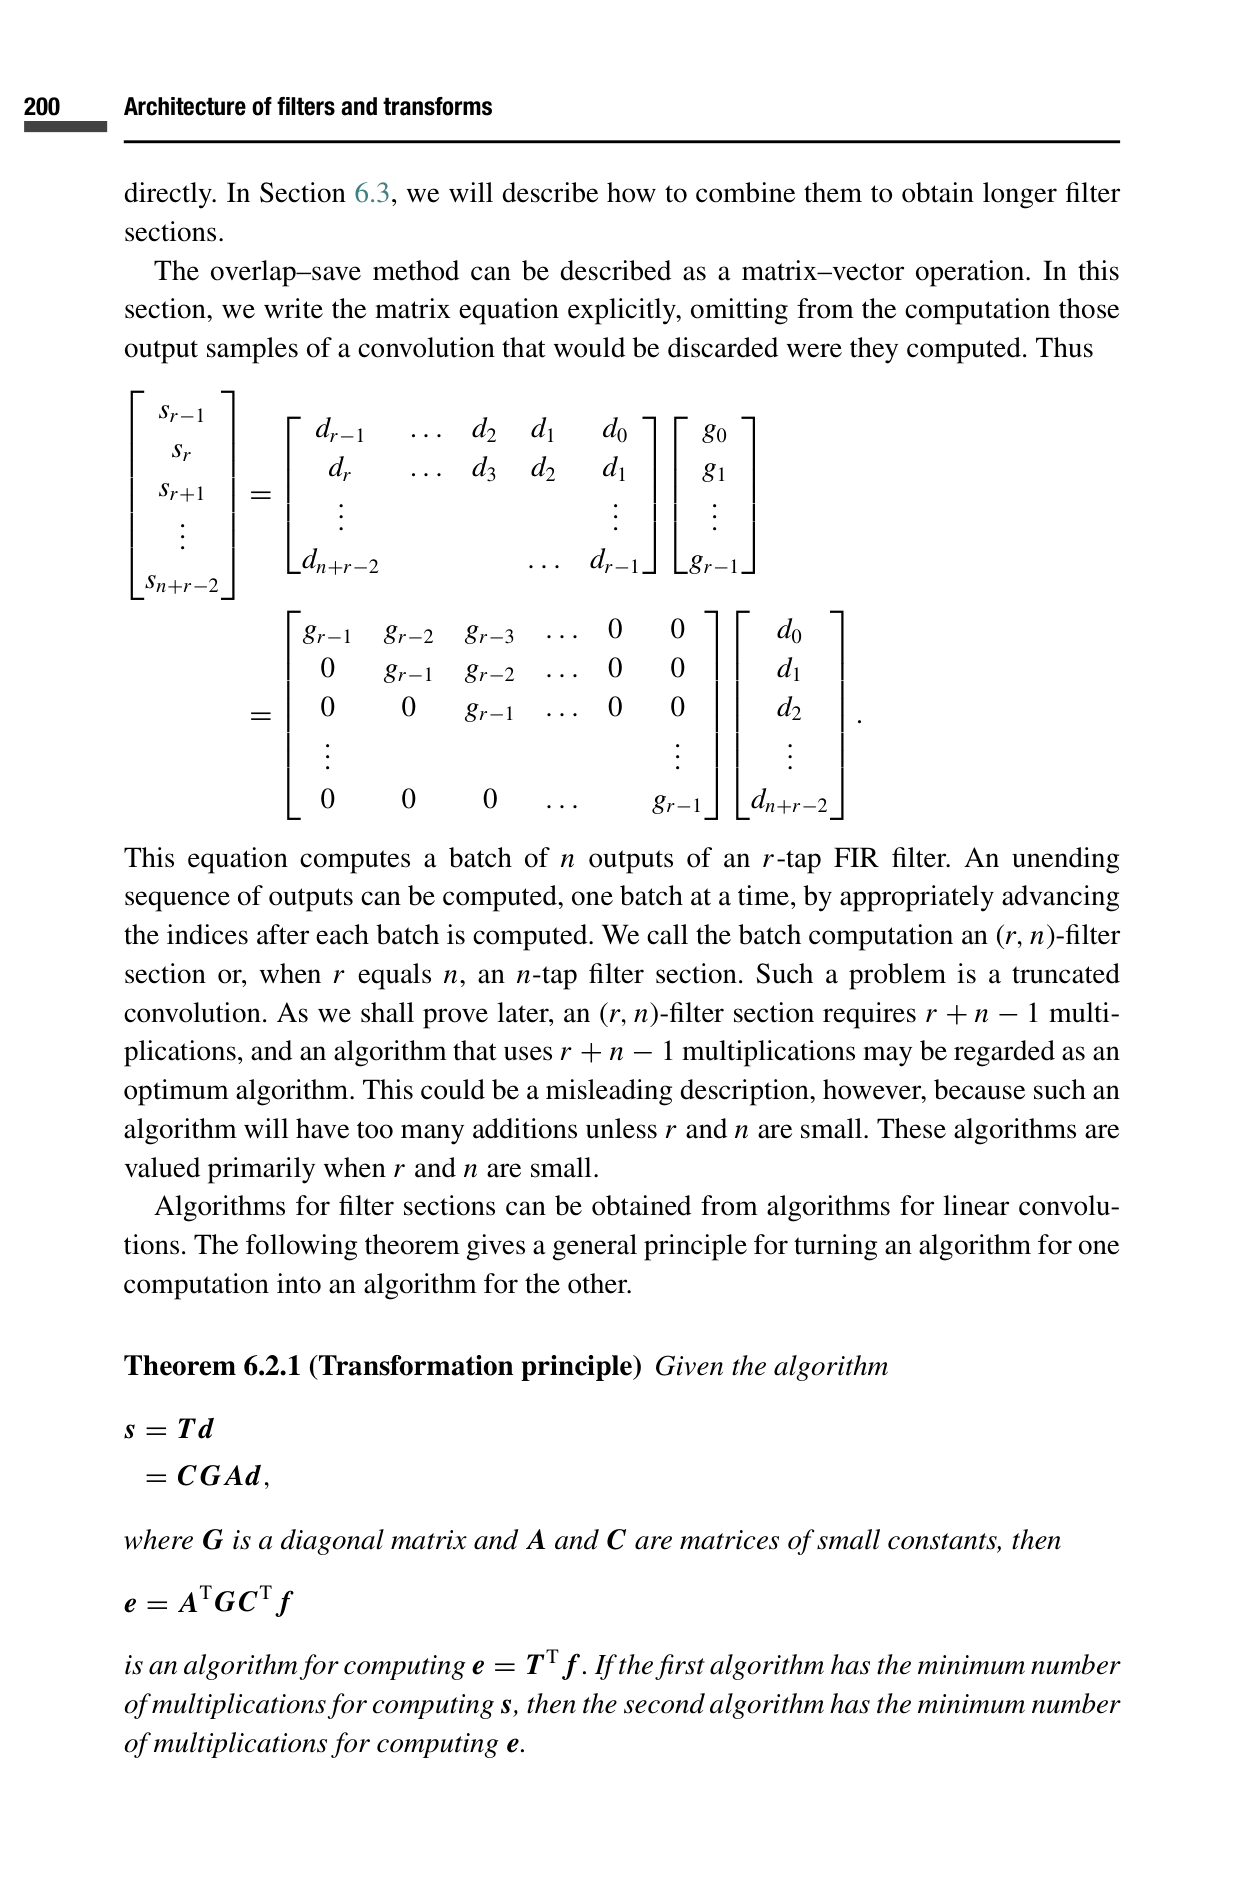

In [6]:
plot_pdf(doc[215], [0, 1])

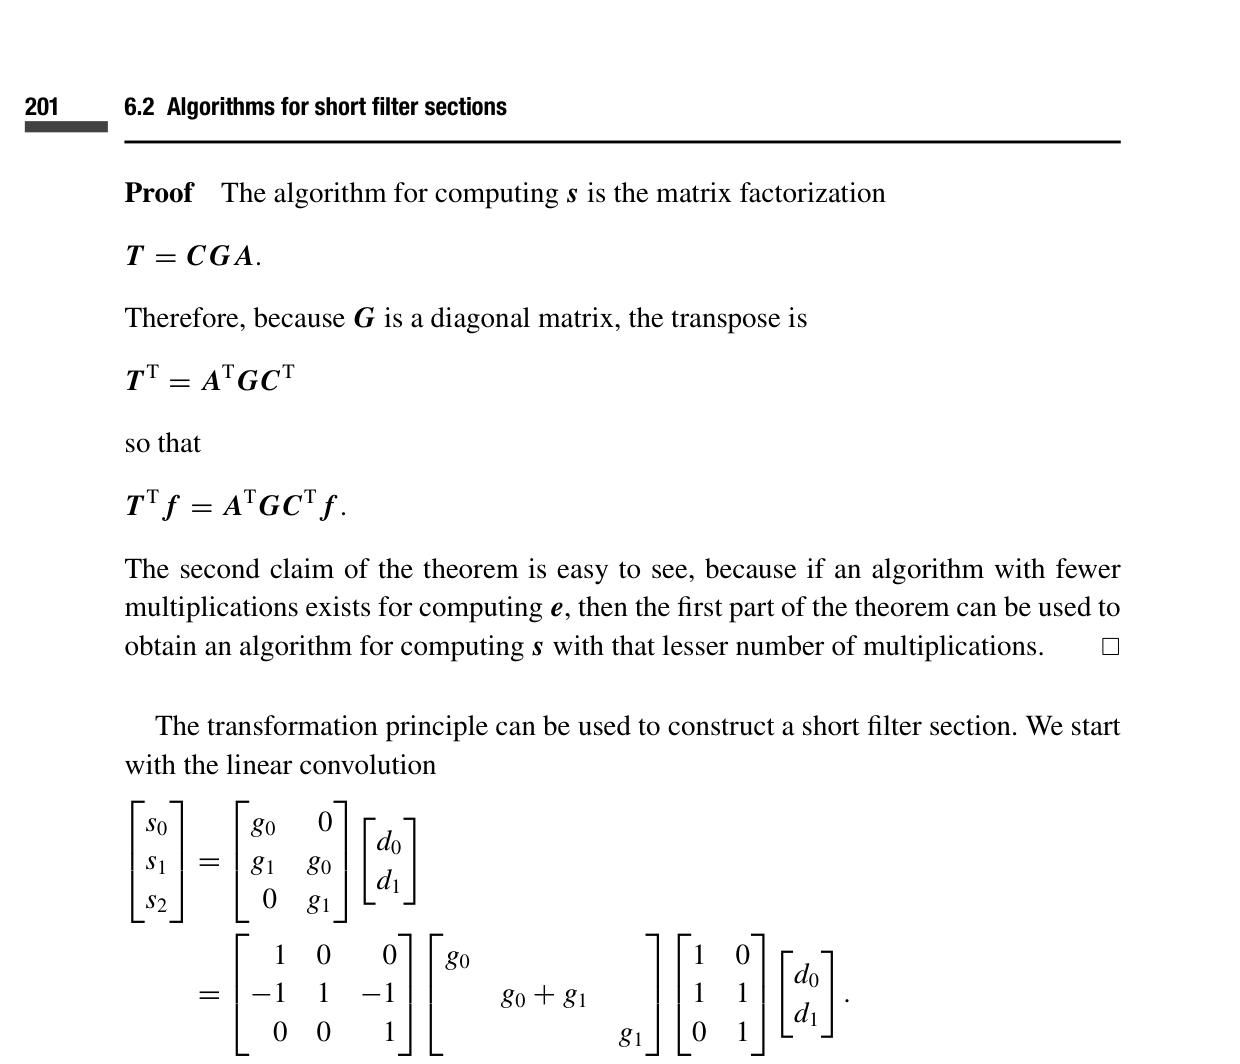

In [7]:
plot_pdf(doc[216], [0, .56])

Size of vectors

In [8]:
d_num = 2
g_num = 2
f_num = 4

Example of vectors for the convolution

In [9]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
f_values = list(range(1, f_num+1))
print(d_values, g_values, f_values)

[1, 2] [1, 2] [1, 2, 3, 4]


Polynomial degree

In [10]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [11]:
x = sy.symbols("x")
x

x

In [12]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1]])

In [13]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [14]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x

In [15]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [16]:
sx = gx*dx
sx

(d_0 + d_1*x)*(g_0 + g_1*x)

Just defining values of matrices

In [17]:
a_mtx = sy.Matrix([[1, 0], [1, 1], [0, 1]])
a_mtx

Matrix([
[1, 0],
[1, 1],
[0, 1]])

In [18]:
b_mtx = sy.Matrix([[1, 0], [1, 1], [0, 1]])
b_mtx

Matrix([
[1, 0],
[1, 1],
[0, 1]])

In [19]:
bg_mtx = sy.diag(*(b_mtx*gi).tolist())
bg_mtx

Matrix([
[g_0,         0,   0],
[  0, g_0 + g_1,   0],
[  0,         0, g_1]])

In [20]:
c_mtx = sy.Matrix([
    [1, 0, -0],
    [-1 , 1, -1],
    [0, 0, 1],
])
c_mtx

Matrix([
[ 1, 0,  0],
[-1, 1, -1],
[ 0, 0,  1]])

In [21]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
se

Matrix([
[ 1, 0,  0],
[-1, 1, -1],
[ 0, 0,  1]])*Matrix([
[g_0,         0,   0],
[  0, g_0 + g_1,   0],
[  0,         0, g_1]])*Matrix([
[1, 0],
[1, 1],
[0, 1]])*Matrix([
[d_0],
[d_1]])

In [22]:
se = sy.MatMul(c_mtx * bg_mtx * a_mtx, di)
se

Matrix([
[g_0,   0],
[g_1, g_0],
[  0, g_1]])*Matrix([
[d_0],
[d_1]])

In [23]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

In [24]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

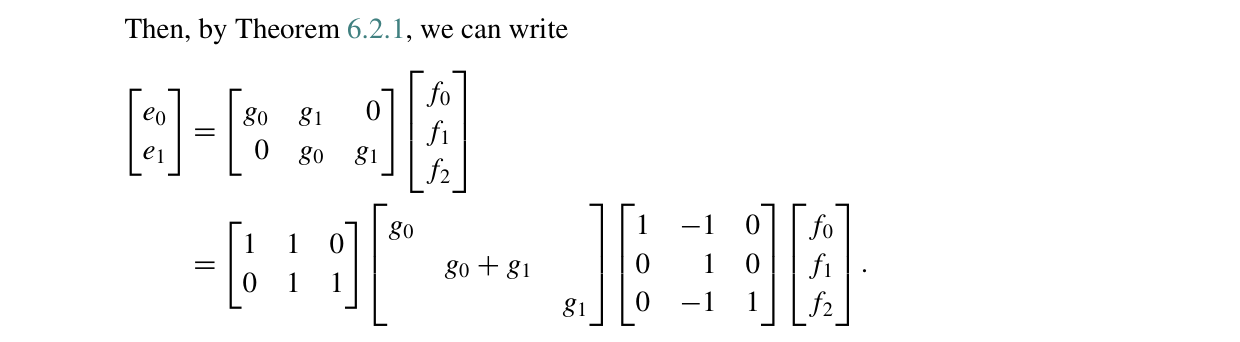

In [25]:
plot_pdf(doc[216], [.56, .74])

In [26]:
fi = sy.Matrix(sy.symbols(" ".join(f"f_{i}"for i in range(c_mtx.T.shape[0]))))
fi

Matrix([
[f_0],
[f_1],
[f_2]])

In [27]:
se = sy.MatMul(a_mtx.T, bg_mtx, c_mtx.T, fi)
se

Matrix([
[1, 1, 0],
[0, 1, 1]])*Matrix([
[g_0,         0,   0],
[  0, g_0 + g_1,   0],
[  0,         0, g_1]])*Matrix([
[1, -1, 0],
[0,  1, 0],
[0, -1, 1]])*Matrix([
[f_0],
[f_1],
[f_2]])

In [28]:
sy.MatMul(a_mtx.T * bg_mtx * c_mtx.T, fi)

Matrix([
[g_0, g_1,   0],
[  0, g_0, g_1]])*Matrix([
[f_0],
[f_1],
[f_2]])

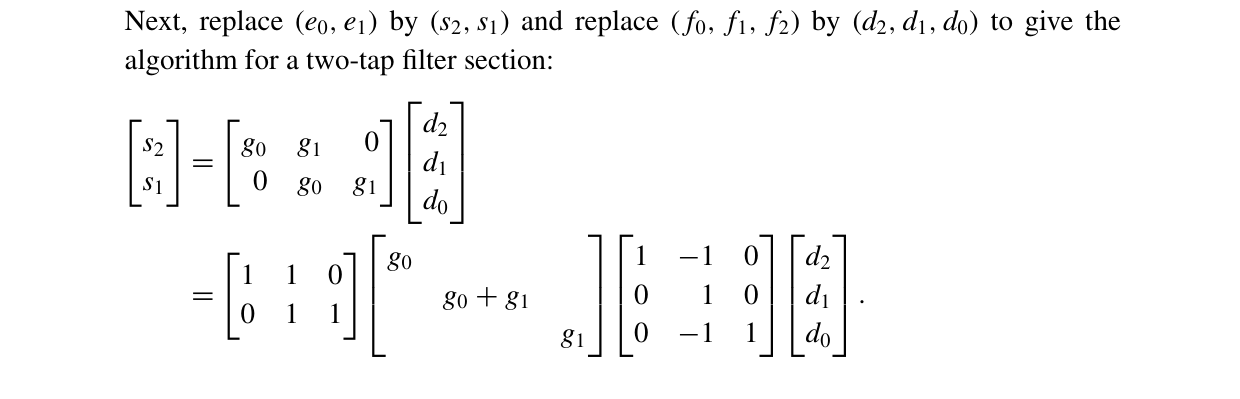

In [29]:
plot_pdf(doc[216], [.74, .95])

Is not necessary to make that part because is same thing that anterior.

## Example

In [30]:
sy.MatMul(a_mtx.T, bg_mtx, c_mtx.T, fi, evaluate=True)

Matrix([
[f_0*g_0 + f_1*g_1],
[f_1*g_0 + f_2*g_1]])

In [31]:
sy.Matrix(np.convolve(f_values, g_values))

Matrix([
[ 1],
[ 4],
[ 7],
[10],
[ 8]])

In [32]:
g_subs = {k[0]: v for k, v in zip(gi.tolist(), g_values)}

In [33]:
f_subs = {k[0]: v for k, v in zip(fi.tolist(), [2, 1, 0])}
se.subs({**g_subs, **f_subs}).T

Matrix([[4, 1]])

In [34]:
f_subs = {k[0]: v for k, v in zip(fi.tolist(), [4, 3, 2])}
se.subs({**g_subs, **f_subs}).T

Matrix([[10, 7]])

In [35]:
f_subs = {k[0]: v for k, v in zip(fi.tolist(), [0, 0, 4])}
se.subs({**g_subs, **f_subs}).T

Matrix([[0, 8]])

In [46]:
ctf = c_mtx.T * sy.Matrix([2, 1, 0])
ctf

Matrix([
[ 1],
[ 1],
[-1]])

In [47]:
bg_ctf = bg_mtx.subs(g_subs) * ctf
bg_ctf

Matrix([
[ 1],
[ 3],
[-2]])

In [48]:
a_mtx.T * bg_ctf

Matrix([
[4],
[1]])

In [53]:
ctf = np.matmul(c_mtx.T, [2, 1, 0])
ctf

array([1, 1, -1], dtype=object)

In [54]:
bg_ctf = np.matmul(bg_mtx.subs(g_subs), ctf)
bg_ctf

array([1, 3, -2], dtype=object)

In [55]:
np.matmul(a_mtx.T, bg_ctf)

array([4, 1], dtype=object)

In [39]:
xm = sy.Matrix([
 [1, 0, 0, 1, 2, 2],
 [2, 1, 0, 0, 1, 2],
 [2, 2, 1, 0, 0, 1],
 [1, 2, 2, 1, 0, 0],
 [0, 1, 2, 2, 1, 0],
 [0, 0, 1, 2, 2, 1],
])
xm

Matrix([
[1, 0, 0, 1, 2, 2],
[2, 1, 0, 0, 1, 2],
[2, 2, 1, 0, 0, 1],
[1, 2, 2, 1, 0, 0],
[0, 1, 2, 2, 1, 0],
[0, 0, 1, 2, 2, 1]])

In [40]:
hm = sy.Matrix([1, 2, 3, 0, 0, 0])
hm

Matrix([
[1],
[2],
[3],
[0],
[0],
[0]])

In [41]:
xm * hm

Matrix([
[ 1],
[ 4],
[ 9],
[11],
[ 8],
[ 3]])

In [42]:
xm2 = sy.Matrix([
 [1, 0, 0],
 [2, 1, 0],
 [2, 2, 1],
 [1, 2, 2],
 [0, 1, 2],
 [0, 0, 1],
])
xm2

Matrix([
[1, 0, 0],
[2, 1, 0],
[2, 2, 1],
[1, 2, 2],
[0, 1, 2],
[0, 0, 1]])

In [43]:
hm2 = sy.Matrix([1, 2, 3])
hm2

Matrix([
[1],
[2],
[3]])

In [44]:
xm2 * hm2

Matrix([
[ 1],
[ 4],
[ 9],
[11],
[ 8],
[ 3]])

In [45]:
sy.Matrix(np.convolve(hm2.values(), xm.tolist()[0]))

Matrix([
[ 1],
[ 2],
[ 3],
[ 1],
[ 4],
[ 9],
[10],
[ 6]])